# Diffusion Models and Flow Matching
## From image generation to protein design

**An interactive academic lecture · English edition · 35–45 minutes**

**Part I.** Probability paths, denoising, scores and velocity fields.  
**Part II.** Two pretrained models actually run on **delta**: Stable Diffusion v1.5 and FrameFlow.

The notebook combines mathematical explanations, lightweight teaching experiments,
embedded generation videos, and time-step controls over recorded model outputs.

> **Two kernels are registered.** *Diffusion and Flow Lecture (GPU)* runs both pretrained models live
> (about one to two minutes in total on one NVIDIA A40) and builds every animation from that fresh run.
> *Diffusion and Flow Lecture (CPU)* skips inference and shows the recorded A100 run instead.
>
> For the live version start JupyterLab from an A40 allocation on delta
> (`bash gpu_shell_a40.sh`, then `bash launch_jupyter_gpu.sh`), choose the GPU kernel and use
> **Run → Run All Cells**. Section 18 lists the exact commands. Live results are written to
> `notebooks/live/`; the recorded run in `notebooks/assets/` is never overwritten.
> Time sliders need an active kernel and execution of their cells.

## 0. Before you start: get a GPU node, then pick the kernel

The kernel cannot allocate its own GPU node, so this happens before the notebook is opened.

**Open OnDemand.**

1. Open <https://openondemand.delta.ncsa.illinois.edu> and sign in with the delta credentials.
2. *Interactive Apps → Jupyter Lab*. Fill in the form:

   | Field | Value |
   |:--|:--|
   | Account | `bcrc-delta-gpu` |
   | Partition | `gpuA40x4-interactive` (at most 1 hour, usually starts within minutes) or `gpuA40x4` for longer sessions |
   | Duration | `1:00:00` (or longer on `gpuA40x4`) |
   | Cores / Memory / GPUs | 8 cores, 32 GB, 1 GPU |
   | Working directory | `/work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927/notebooks` |

   The working directory must be one you can write to. Leaving it at `/work` makes JupyterLab open at the
   file-system root, and saving or creating notebooks there fails with *Permission denied*.
3. *Launch*, wait until the session card says *Running*, then *Connect to Jupyter*. The notebook directory opens
   directly; double-click `Diffusion_Flow_Matching_Lecture_English.ipynb`.

**Register the two lecture kernels (once per user, before the first session).** On a delta login node run

```bash
bash /work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927/register_kernels.sh
```

Open OnDemand starts JupyterLab from the system module `pytorch-conda/2.8`, which only looks for kernels in its own
directory and in your `~/.local/share/jupyter/kernels/`. The lecture environments live inside this project's `envs/`,
so without this step the GPU kernel below does not appear in the kernel list and the notebook silently falls back
to the recorded run under the default *Python 3* kernel. The script only copies two small `kernel.json` files
into your home directory; nothing is installed.

**Choose the kernel / Python environment.**

| Kernel name in Jupyter | Interpreter | What happens in this notebook |
|:--|:--|:--|
| **Diffusion and Flow Lecture (GPU)** — use this on the A40 node | `envs/lecture/bin/python` (PyTorch 2.5.1 + CUDA 12.4, Diffusers, FrameFlow deps) | Sections 11 and 15 run Stable Diffusion and FrameFlow live; all later outputs come from that run |
| Diffusion and Flow Lecture (CPU) | `envs/notebook/bin/python` (NumPy, Matplotlib, ipywidgets only) | No inference; the recorded A100 run is shown |
| Python 3 (ipykernel) — Open OnDemand's default | system conda environment | Not usable: it lacks Diffusers and the FrameFlow dependencies |

The kernel name is shown in the top-right corner of the notebook; click it (or *Kernel → Change Kernel…*) to switch.
The GPU kernel also works on a login node: it detects that no GPU is visible and falls back to the recorded run.

**Executing cell by cell.** Run the first code cell below first; it prints the kernel path and the mode
(LIVE GPU or recorded). Then run cells in order with Shift+Enter, or *Run → Run All Cells*.
The two inference cells (Sections 11 and 15) show a status line, a progress bar and the current frame updating in
place; the first image run takes 2–3 minutes on an A40, most of it loading the 2 GB weights before the bar starts
moving, so do not interrupt the cell. If this notebook was changed on disk while it was open, use
*File → Reload Notebook from Disk* before running or saving, otherwise the browser copy overwrites the file.

In [1]:
from pathlib import Path
import io, json, base64, html, sys, os, platform, time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image as PILImage
from IPython.display import display, Markdown, HTML, Video, Image
import ipywidgets as widgets

DELTA_ROOT = Path('/work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927')
candidates = [Path.cwd(), Path.cwd()/'notebooks', Path.cwd()/'outputs/notebooks', DELTA_ROOT/'notebooks']
NOTEBOOK_DIR = next((p for p in candidates if (p/'assets/image.json').is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError('Open this notebook from the supplied notebooks directory, with assets/ beside it.')
ASSETS = NOTEBOOK_DIR/'assets'       # recorded A100 run: read-only reference
LIVE = Path(os.environ.get('LECTURE_LIVE_DIR', NOTEBOOK_DIR/'live'))   # fresh GPU runs made by this notebook go here
LECTURE_ROOT = NOTEBOOK_DIR.parent

# ---- execution mode ----------------------------------------------------------
# GPU kernel with a visible CUDA device -> both models are run live in Sections 11 and 15.
# Anything else                         -> the recorded trajectories are loaded.
# Set FORCE_RECORDED = True to present the recorded run even on a GPU node.
FORCE_RECORDED = False
demos, gpu = None, None
try:
    sys.path.insert(0, str(LECTURE_ROOT))
    import lecture_demos as demos    # shared inference code, also used by the Slurm scripts
    from lecture_widgets import LiveMonitor   # progress bar + live frame display for the demos
    gpu = demos.gpu_summary()        # None when torch sees no CUDA device
except ImportError:
    pass                             # CPU kernel: torch and diffusers are not installed there
RUN_GPU_INFERENCE = gpu is not None and not FORCE_RECORDED

# Sections 11 and 15 redirect these to the live directories after a successful run.
IMAGE_DIR, PROTEIN_DIR = ASSETS, ASSETS
image_meta = json.loads((ASSETS/'image.json').read_text())
protein_meta = json.loads((ASSETS/'protein.json').read_text())
RECORDED_JOBS = {'image': 22456504, 'protein': 22456441}

def run_source(directory, kind):
    return 'live run from this notebook' if directory != ASSETS else f'recorded run, Slurm job {RECORDED_JOBS[kind]}'

plt.rcParams.update({'figure.dpi':110, 'font.size':12, 'axes.spines.top':False,
                     'axes.spines.right':False, 'axes.titleweight':'bold'})
BLUE, ORANGE = '#315AA2', '#D8743A'
print('Notebook directory:', NOTEBOOK_DIR.resolve())
print('Kernel:', sys.executable)
if RUN_GPU_INFERENCE:
    print(f"Mode: LIVE GPU inference on {gpu['name']} @ {gpu['host']} "
          f"({gpu['memory_free_GB']} of {gpu['memory_total_GB']} GB free) + CPU teaching examples")
elif gpu is not None:
    print('Mode: recorded model trajectories (FORCE_RECORDED) + CPU teaching examples')
else:
    print('Mode: recorded model trajectories + CPU teaching examples (no CUDA device in this kernel)')

Notebook directory: /work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927/notebooks
Kernel: /sw/rh9.4/user/python/conda-env/pytorch-2.8-cu128/bin/python
Mode: LIVE GPU inference on NVIDIA A100-SXM4-40GB @ gpua045.delta.ncsa.illinois.edu (42.0 of 42.4 GB free) + CPU teaching examples


# Part I · The principles

## 1. One common goal: transport a simple distribution into data

A generative model learns a distribution from examples and produces new samples.
Both diffusion and flow matching use a **time-conditioned neural network** and repeated updates.
The evolving distribution is distinct from the trajectory of any one sample.

| Notation in this lecture | Initial state | Final state | Generation direction |
|:--|:--|:--|:--|
| Diffusion index $k$ | $x_K$ is approximately Gaussian noise | $x_0$ is data | $K\rightarrow 0$ |
| Flow time $t$ | $x(0)=z\sim\mathcal N(0,I)$ | $x(1)$ follows the data distribution | $0\rightarrow 1$ |
| Image demo progress $s$ | $s=0$ | $s=1$ | $s=i/N$ over inference steps |

**Watch the time convention.** A decreasing diffusion index and an increasing flow time
can both describe progress toward a generated sample.

Sources: [DDPM](https://arxiv.org/abs/2006.11239), [Flow Matching](https://arxiv.org/abs/2210.02747).

## 2. Diffusion: define a forward noising process

Let $\beta_k\in(0,1)$, $\alpha_k=1-\beta_k$ and $\bar\alpha_k=\prod_{j=1}^{k}\alpha_j$.
The forward Markov chain is

$$q(x_k\mid x_{k-1})=\mathcal N\!\left(\sqrt{\alpha_k}x_{k-1},\beta_k I\right).$$

Its marginal can be sampled directly:

$$x_k=\sqrt{\bar\alpha_k}x_0+\sqrt{1-\bar\alpha_k}\,\epsilon,
\qquad \epsilon\sim\mathcal N(0,I).$$

We do not need to simulate all previous steps to construct a training example at index $k$.
For an appropriate schedule, the signal-to-noise ratio becomes small near $K$.

**Teaching experiment below:** add Gaussian noise to the final generated image in **pixel space**.
The panels share one noise sample to make comparison easy; they are marginal samples coupled
by the same noise, **not** a forward Markov-chain realization. The real Stable Diffusion demo
later operates in latent space.

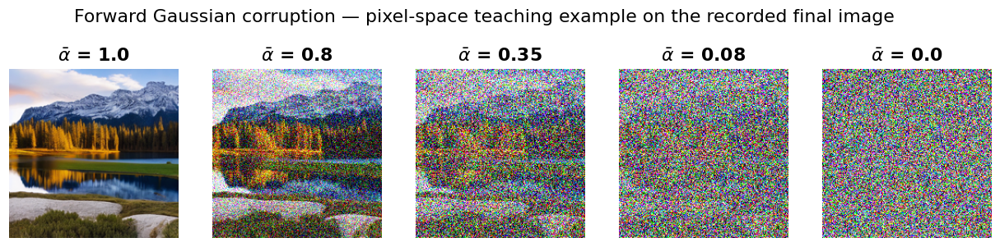

In [2]:
rng = np.random.default_rng(2026)
x0 = np.asarray(PILImage.open(ASSETS/'final.png').convert('RGB').resize((192,192)), dtype=float)/127.5-1
noise = rng.normal(size=x0.shape)
alpha_bars = [1.0, 0.80, 0.35, 0.08, 0.0]
fig, axes = plt.subplots(1, len(alpha_bars), figsize=(14,3))
for ax, a in zip(axes, alpha_bars):
    xk = np.sqrt(a)*x0 + np.sqrt(1-a)*noise
    ax.imshow(np.clip((xk+1)/2,0,1))
    ax.set_title(r'$\bar\alpha$ = '+str(a)); ax.axis('off')
fig.suptitle('Forward Gaussian corruption — pixel-space teaching example on the recorded final image', y=1.03)
plt.show()

## 3. Learn denoising by predicting the injected noise

Training samples a data example $x_0$, a timestep $k$, and noise $\epsilon$.
The simplified DDPM objective is

$$\mathcal L_{\mathrm{simple}}(\theta)
=\mathbb E_{x_0,k,\epsilon}\left[
\|\epsilon-\epsilon_\theta(x_k,k)\|_2^2\right].$$

The network sees the noisy state and its time index; the known noising process supplies the target.
One network is shared across timesteps. At the optimum of this squared loss,
$\epsilon_\theta(x_k,k)$ estimates a conditional mean rather than memorizing the particular noise draw.

The corresponding clean-data prediction is

$$\widehat x_0(x_k,k)=
\frac{x_k-\sqrt{1-\bar\alpha_k}\,\epsilon_\theta(x_k,k)}{\sqrt{\bar\alpha_k}}.$$

This is the simplified noise-prediction loss, not the full term-by-term variational bound.

## 4. Generate by stepping backward

A standard DDPM reverse mean under noise parameterization is

$$\mu_\theta(x_k,k)=\frac{1}{\sqrt{\alpha_k}}
\left(x_k-\frac{\beta_k}{\sqrt{1-\bar\alpha_k}}\epsilon_\theta(x_k,k)\right).$$

Sampling then uses

$$x_{k-1}=\mu_\theta(x_k,k)+\sigma_k\xi,\qquad \xi\sim\mathcal N(0,I),$$

with the random term usually omitted at the final step. The variance convention determines $\sigma_k$.

**DDIM** can reuse a trained denoiser with a different sampling procedure.
For a deterministic DDIM update from index $k$ to a lower index $j$,

$$x_j=\sqrt{\bar\alpha_j}\,\widehat x_0+
\sqrt{1-\bar\alpha_j}\,\epsilon_\theta(x_k,k).$$

Our image run uses **DDIM with $\eta=0$**, so a fixed initial noise state and conditioning give a deterministic sampling trajectory, subject to implementation details.

Sources: [DDPM](https://arxiv.org/abs/2006.11239), [DDIM](https://arxiv.org/abs/2010.02502).

## 5. Scores connect denoising with continuous dynamics

The score points in the direction of locally increasing log density:

$$s_k(x)=\nabla_x\log p_k(x).$$

For Gaussian perturbations, the noise and marginal-score regressors are related by

$$s_\theta(x_k,k)=-\frac{\epsilon_\theta(x_k,k)}{\sqrt{1-\bar\alpha_k}}.$$

For a continuous forward SDE $dx=f(x,\tau)d\tau+g(\tau)dW_\tau$, the probability-flow ODE is

$$\frac{dx}{d\tau}=f(x,\tau)-\frac12 g(\tau)^2\nabla_x\log p_\tau(x).$$

Under the usual assumptions and an exact score, it shares the SDE's one-time marginal distributions.
Generation integrates from high-noise time toward data time.
**Diffusion is therefore not restricted to stochastic generation.**

Source: [Score-Based Generative Modeling through SDEs](https://arxiv.org/abs/2011.13456).

## 6. Flow matching: learn a velocity field

A continuous flow transports samples through an ODE:

$$\frac{dx(t)}{dt}=v_\theta(x(t),t),\qquad x(0)=z\sim p_0.$$

The induced density satisfies the continuity equation,

$$\partial_t p_t(x)+\nabla_x\!\cdot\!\left(p_t(x)v_t(x)\right)=0.$$

Flow matching specifies a probability path and regresses a velocity field compatible with that path.
The challenge is that the marginal target velocity is generally difficult to compute directly.
**Conditional paths provide tractable training targets.**

## 7. Conditional flow matching with a linear path

Take independently paired noise $z\sim\mathcal N(0,I)$ and data $y\sim p_{\mathrm{data}}$:

$$x_t=(1-t)z+ty,\qquad u_t=y-z.$$

The conditional flow-matching objective is

$$\mathcal L_{\mathrm{CFM}}(\theta)=
\mathbb E_{t,z,y}\left[\|v_\theta(x_t,t)-(y-z)\|_2^2\right].$$

The squared-loss optimum is the **average conditional velocity**

$$v^*(x,t)=\mathbb E[y-z\mid x_t=x].$$

The network receives only $(x,t)$ at generation time; it does not know a target data endpoint.
Individual conditional paths are straight here, while trajectories of the marginal velocity field
can be curved. Other couplings, schedules and paths change the target.

Source: [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747).

In [3]:
# A minibatch of exact conditional training targets; no neural-network training here.
rng = np.random.default_rng(7)
means = np.array([[-2,-2],[-2,2],[2,-2],[2,2]], dtype=float)
sigma_data = 0.25
z = rng.normal(size=(800,2))
classes = rng.integers(0,4,size=len(z))
y = means[classes] + sigma_data*rng.normal(size=z.shape)
t = rng.uniform(size=(len(z),1))
x_t = (1-t)*z+t*y
velocity_target = y-z
print('Network inputs: x_t', x_t.shape, 'and t', t.shape)
print('Regression targets:', velocity_target.shape)

Network inputs: x_t (800, 2) and t (800, 1)
Regression targets: (800, 2)


## 8. An exact toy flow you can inspect

Use four equally weighted Gaussian data components with centers $\mu_c$ and variance
$\sigma_d^2I$. For the linear path, each marginal component has mean $t\mu_c$ and variance

$$a_t=(1-t)^2+t^2\sigma_d^2.$$

With posterior component weights $w_c(x,t)=P(c\mid x_t=x)$, the exact marginal velocity is

$$v(x,t)=\sum_c w_c(x,t)\left[
\mu_c+\frac{t\sigma_d^2-(1-t)}{a_t}(x-t\mu_c)\right].$$

We can therefore demonstrate sampling without training a network. In realistic problems,
a neural model approximates the corresponding velocity instead.
The code below uses a second-order midpoint ODE solver; finite steps introduce numerical error.

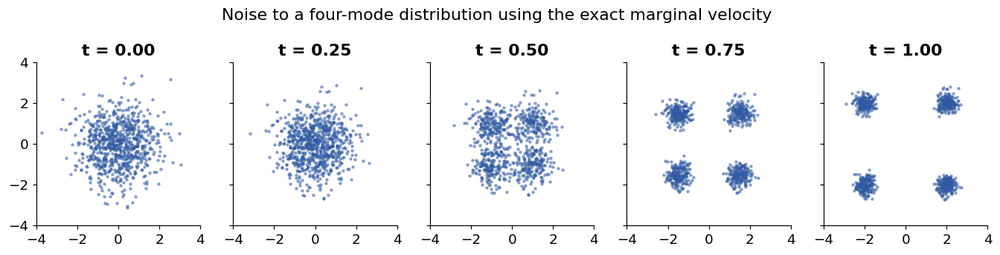

In [4]:
def exact_velocity(x, t):
    variance = (1-t)**2 + (t*sigma_data)**2
    residual = x[:,None,:] - t*means[None,:,:]
    logw = -(residual**2).sum(axis=-1)/(2*variance)
    logw -= logw.max(axis=1,keepdims=True)
    w = np.exp(logw); w /= w.sum(axis=1,keepdims=True)
    conditional = means[None,:,:] + ((t*sigma_data**2-(1-t))/variance)*residual
    return (w[:,:,None]*conditional).sum(axis=1)

rng = np.random.default_rng(2026)
flow_times = np.linspace(0,1,101)
state = rng.normal(size=(800,2))
flow_states = [state.copy()]
for ta,tb in zip(flow_times[:-1],flow_times[1:]):
    dt=tb-ta
    midpoint=state+0.5*dt*exact_velocity(state,ta)
    state=state+dt*exact_velocity(midpoint,ta+dt/2)
    flow_states.append(state.copy())
flow_states=np.stack(flow_states)
fig, axes=plt.subplots(1,5,figsize=(15,3),sharex=True,sharey=True)
for ax,j in zip(axes,[0,25,50,75,100]):
    ax.scatter(*flow_states[j].T,s=4,alpha=.45,color=BLUE)
    ax.set(xlim=(-4,4),ylim=(-4,4),title=f't = {flow_times[j]:.2f}',aspect='equal')
fig.suptitle('Noise to a four-mode distribution using the exact marginal velocity',y=1.05)
plt.show()

In [5]:
# Scrub model time. This toy is mathematical illustration, not either pretrained demo.
def show_toy(frame=50):
    fig,ax=plt.subplots(figsize=(5.5,5))
    ax.scatter(*flow_states[frame].T,s=8,alpha=.5,color=BLUE)
    for i in range(0,160,8):
        ax.plot(flow_states[:frame+1,i,0],flow_states[:frame+1,i,1],color=ORANGE,alpha=.7,lw=1)
    ax.set(xlim=(-4,4),ylim=(-4,4),aspect='equal',title=f'Exact marginal flow: t = {flow_times[frame]:.2f}')
    display(fig); plt.close(fig)   # display() instead of plt.show(): plt.show() stalls inside a widget Output in the GPU kernel
toy_slider=widgets.IntSlider(value=50,min=0,max=100,description='Time step',continuous_update=False)
display(widgets.VBox([toy_slider,widgets.interactive_output(show_toy,{'frame':toy_slider})]))

## 9. Diffusion and flow matching in one framework

A Gaussian path can be written as

$$x_t=\alpha(t)y+\sigma(t)z.$$

A conditional velocity target is then

$$u_t=\dot\alpha(t)y+\dot\sigma(t)z.$$

Noise, score, clean-data and velocity predictions can be related under suitable schedules
and away from singular endpoints. These conversions change time-dependent loss weights;
they do not make every training or sampling implementation identical.

| Dimension | Diffusion (common formulation) | Flow matching (common formulation) |
|:--|:--|:--|
| Path | Noise-corrupted data marginals | A chosen probability path |
| Regression target | Noise, score or clean data | Conditional velocity, or an equivalent parameterization |
| Generation | Reverse SDE, DDIM or probability-flow ODE | Numerical ODE integration |
| Time conditioning | Noise level / timestep | Position along the flow |
| Design choices | Schedule, parameterization, variance, sampler | Path, coupling, parameterization, solver |

**Architecture, objective and sampler are separate choices.** Neither approach automatically guarantees fewer steps or better quality.

# Part II · Applications and real inference demos

## 10. Image generation: an early, widely explored application

- **2015:** foundational diffusion generative modeling.
- **2020:** DDPM demonstrated influential image-generation results.
- **2022:** latent diffusion enabled high-resolution, text-conditioned synthesis.

Image generation was an early mainstream application; it was not the only application.
Our reproducible example uses **Stable Diffusion v1.5**, a pretrained latent diffusion model.

**Pipeline:** prompt → text embedding → repeated latent denoising → VAE decoder → image.

The VAE compresses pixels into a smaller latent space. A time-conditioned U-Net predicts noise
under text conditioning. The decoded noisy latent is a visualization of an internal state,
not a pixel-space DDPM state.

Sources: [Sohl-Dickstein et al.](https://arxiv.org/abs/1503.03585),
[DDPM](https://arxiv.org/abs/2006.11239), [Latent Diffusion](https://arxiv.org/abs/2112.10752).

## 11. Text conditioning and classifier-free guidance

For a conditional prediction $\epsilon_c$ and a baseline prediction $\epsilon_b$,

$$\epsilon_{\mathrm{guided}}=\epsilon_b+w(\epsilon_c-\epsilon_b).$$

In this run the baseline branch uses a **negative prompt** rather than empty text.
Increasing $w$ changes adherence and diversity; it does not guarantee better image quality.

The actual settings are shown below. Timesteps decrease from 981 to 0 across the recorded states.
The right panel predicts a clean endpoint from the preceding model evaluation; after an update,
its model timestep differs from the current latent's timestep.

Sources: [Classifier-Free Guidance](https://arxiv.org/abs/2207.12598),
[Stable Diffusion v1.5 model card](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5).

### Demo 1 · Run Stable Diffusion now (GPU kernel)

The next cell performs **real inference** when the notebook runs on the GPU kernel with a CUDA device:
it loads Stable Diffusion v1.5 in fp16, samples with DDIM for the chosen number of steps, and decodes
**every** intermediate latent and clean prediction through the VAE (51 frames, two decodes each at 50 steps).
The frames, GIF, MP4, latent trajectory and metadata go to `notebooks/live/image_generation/`.
Expect roughly 30–60 s on one A40 for the first run; later runs skip the model load.

Edit `PROMPT`, `IMAGE_SEED` or `IMAGE_STEPS` and re-run this cell and the ones below it to generate a new
sample during the lecture. On the CPU kernel the cell only reports which recorded run is shown.

In [6]:
# Demo 1 parameters. Edit and re-run during the lecture (GPU kernel only).
IMAGE_SEED  = 2026
IMAGE_STEPS = 50
PROMPT   = demos.DEFAULT_PROMPT   if demos else image_meta['prompt']
NEGATIVE = demos.DEFAULT_NEGATIVE if demos else image_meta['negative_prompt']

if RUN_GPU_INFERENCE:
    out = LIVE/'image_generation'
    # Live view: left = decoded current latent, right = decoded clean prediction, updated after every DDIM step.
    monitor = LiveMonitor('DDIM step', IMAGE_STEPS)
    t0 = time.perf_counter()
    image_meta = demos.run_image_demo(seed=IMAGE_SEED, steps=IMAGE_STEPS, out_dir=out, prompt=PROMPT, negative=NEGATIVE,
                                      progress=None, status=monitor.status, frame_callback=monitor.step)
    IMAGE_DIR = out
    monitor.done(f"Finished: {image_meta['elapsed_seconds_including_decoding']:.1f} s sampling+decoding, "
                 f"{time.perf_counter()-t0:.1f} s wall time including model load and video encoding, on {image_meta['gpu']}")
    print('Written to', out)
else:
    print('No live inference in this kernel. Showing the', run_source(IMAGE_DIR, 'image'),
          f"({image_meta['gpu']}, host {image_meta['host']}).")

ModuleNotFoundError: No module named 'diffusers'

In [17]:
print('Source:', run_source(IMAGE_DIR, 'image'))
print('Model:', image_meta['model'])
print('Prompt:', image_meta['prompt'])
print('Negative prompt:', image_meta['negative_prompt'])
print('Sampler:', image_meta['scheduler'], '| steps:', image_meta['steps'], '| seed:', image_meta['seed'])
print('Guidance:', image_meta['guidance_scale'], '| GPU:', image_meta['gpu'], '| host:', image_meta['host'])
print(f"Runtime including frame decoding/saving: {image_meta['elapsed_seconds_including_decoding']:.3f} s")
# The video is embedded in the saved notebook outputs for convenient presentation.
display(Video(filename=str(IMAGE_DIR/'image_generation.mp4'),embed=True,width=960,
              html_attributes='controls loop playsinline preload="metadata"'))

Source: live run from this notebook
Model: stable-diffusion-v1-5/stable-diffusion-v1-5
Prompt: A small wooden cabin beside a calm alpine lake, snow capped mountains in the distance, pine forest, golden sunrise, landscape photography, realistic, highly detailed
Negative prompt: blurry, low quality, text, watermark, oversaturated
Sampler: DDIM eta=0 | steps: 50 | seed: 2026
Guidance: 7.5 | GPU: NVIDIA A40 | host: gpub002.delta.ncsa.illinois.edu
Runtime including frame decoding/saving: 25.329 s


In [19]:
# Time controls over the actual inference frames of the active run. No interpolation or new inference.
def gif_time_viewer(gif_path, captions, initial=0):
    image = widgets.Image(format='png',layout=widgets.Layout(width='960px',max_width='100%'))
    label = widgets.HTML()
    slider = widgets.IntSlider(min=0,max=len(captions)-1,value=initial,
                              description='Frame',continuous_update=False,layout=widgets.Layout(width='80%'))
    play = widgets.Play(min=0,max=len(captions)-1,value=initial,interval=180,description='Play')
    link = widgets.jslink((play,'value'),(slider,'value'))
    def update(change=None):
        i=slider.value
        with PILImage.open(gif_path) as im:
            im.seek(i)
            buf=io.BytesIO(); im.convert('RGB').save(buf,format='PNG')
        image.value=buf.getvalue()
        label.value='<b>'+html.escape(captions[i])+'</b>'
    slider.observe(update,names='value'); update()
    box=widgets.VBox([widgets.HBox([play,slider]),label,image])
    box._lecture_link=link
    return box

image_captions=[f"Step {f['step']}/{image_meta['steps']} | progress s={f['generation_progress']:.2f} | current diffusion k={f['diffusion_timestep']} | prediction evaluated at k={f['prediction_model_timestep']}"
                for f in image_meta['frames']]
image_viewer=gif_time_viewer(IMAGE_DIR/'image_generation.gif',image_captions)
display(image_viewer)

## 12. What should we learn from this trajectory?

Judge the run shown above with three questions:

1. **Order of emergence.** In the recorded sample (seed 2026), large-scale scene structure appears before
   finer detail. This does not establish monotonically improving quality at every step; check whether a
   live sample behaves the same way.
2. **Conditioning.** The recorded sample contains a lake, mountains and trees, **but no clear cabin**
   requested by the prompt. A visually plausible sample can still fail part of its conditioning.
   Compare the sample below against every object named in its prompt.
3. **Determinism.** DDIM with $\eta=0$ is deterministic given the initial noise and the conditioning.
   The same seed on the same GPU class reproduces the trajectory up to floating-point differences;
   a different seed or a different GPU architecture can give a different scene.

The image below is the actual saved output of the run shown above, not a separately selected example.

Source: live run from this notebook | NVIDIA A40 | gpub002.delta.ncsa.illinois.edu
Prompt: A small wooden cabin beside a calm alpine lake, snow capped mountains in the distance, pine forest, golden sunrise, landscape photography, realistic, highly detailed
Seed: 2026 | steps: 50 | finished: 2026-09-29 13:31:56


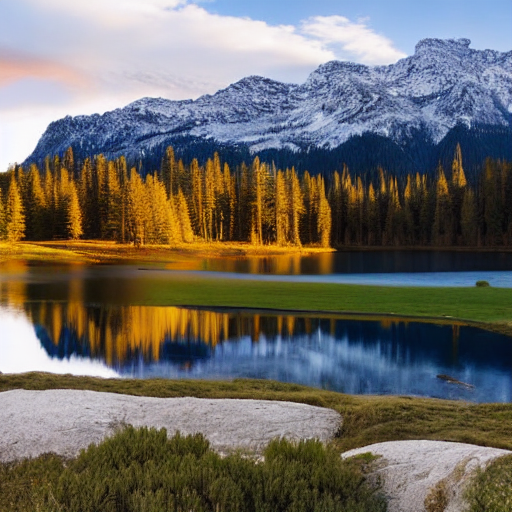

In [20]:
print('Source:', run_source(IMAGE_DIR, 'image'), '|', image_meta['gpu'], '|', image_meta['host'])
print('Prompt:', image_meta['prompt'])
print('Seed:', image_meta['seed'], '| steps:', image_meta['steps'], '| finished:', image_meta.get('finished_at', 'see metadata'))
display(Image(filename=str(IMAGE_DIR/'final.png'),width=512))

## 13. Protein design: an active scientific application in recent years

**RFdiffusion (2023)** and **Chroma (2023)** provided influential examples, including experimental
results. **FrameFlow (2023–2024)** develops protein backbone generation with SE(3) flow matching.

A general design workflow is:

**Structural/function constraints → backbone generation → sequence design → computational evaluation → experiments.**

Our demo covers **unconditional backbone generation**. It uses the official FrameFlow model,
released weights and sampler. It does not run sequence design, refolding, a functional assay
or experimental validation.

Sources: [RFdiffusion](https://doi.org/10.1038/s41586-023-06415-8),
[Chroma](https://doi.org/10.1038/s41586-023-06728-8),
[FrameFlow 2023](https://arxiv.org/abs/2310.05297),
[FrameFlow 2024](https://arxiv.org/abs/2401.04082).

## 14. Represent a protein using residue frames

Residue $i$ has a translation $r_i\in\mathbb R^3$ and orientation $R_i\in SO(3)$.
Together they define a rigid frame $T_i\in SE(3)$; the full state lies in $SE(3)^L$.

- Translation locates the residue, typically using the Cα position.
- Rotation describes the local N–Cα–C backbone orientation.
- Centering removes global translation.
- Equivariance makes a global rigid transformation of the input transform the output consistently.

A Euclidean linear path handles translations:

$$r_t=(1-t)r_0+tr_1.$$

A conditional rotational geodesic can be written

$$R_t=R_0\operatorname{Exp}\!\left[t\operatorname{Log}(R_0^TR_1)\right].$$

The latter is a geometric teaching formula. The released sampler used in this demo employs an
**exponential rotational schedule (rate 10)** and a linear translational schedule. It predicts endpoint
frames and converts them into updates. Do not equate its precise update rule with the simple linear-time formula.

## 15. Demo 2: protein backbone generation as model time increases

**Left:** current generated Cα trace. **Right:** predicted final backbone.
Colors identify residue order; the camera and scale are fixed throughout.
Early line segments indicate sequence adjacency and need not have valid bond lengths.

With the default settings there are 100 sampling timepoints from $t=0.01$ to $t=1$, plus the official
endpoint prediction: 101 stored frames in total. The final extra frame shares $t=1$.

**Model time is a generation coordinate, not physical protein-folding time.**
The right panel is a model prediction, not an experimentally measured target.

### Demo 2 · Run FrameFlow now (GPU kernel)

On the GPU kernel the next cell loads the official FrameFlow model with the released PDB weights, samples
one unconditional backbone with the official `Interpolant.sample`, saves the coordinates and PDB files,
and renders every stored frame with a fixed camera into a GIF and an MP4 in `notebooks/live/protein_design/`.
Sampling takes a few seconds on an A40; rendering 101 frames takes about half a minute of CPU time.

Edit `PROTEIN_LENGTH`, `PROTEIN_STEPS` or `PROTEIN_SEED` and re-run this cell and the ones below it.
On the CPU kernel the cell only reports which recorded run is shown.

In [21]:
# Demo 2 parameters. Edit and re-run during the lecture (GPU kernel only).
PROTEIN_LENGTH = 100
PROTEIN_STEPS  = 100
PROTEIN_SEED   = 2026

if RUN_GPU_INFERENCE:
    out = LIVE/'protein_design'
    t0 = time.perf_counter()
    sampling = LiveMonitor('Sampling', PROTEIN_STEPS, show_image=False)      # one bar step per model evaluation
    protein_meta = demos.run_protein_demo(length=PROTEIN_LENGTH, steps=PROTEIN_STEPS, seed=PROTEIN_SEED, out_dir=out,
                                          status=sampling.status, step_callback=sampling.step)
    sampling.done(f"Sampling finished: {protein_meta['inference_seconds']:.3f} s on {protein_meta['gpu']} "
                  f"({protein_meta['trajectory_frames']} stored frames)")
    # Rendering pass: each stored frame is drawn with the fixed camera and shown as soon as it is ready.
    rendering = LiveMonitor('Rendering', protein_meta['trajectory_frames'] - 1)
    demos.render_protein(out, progress=None, frame_callback=rendering.step)
    rendering.done(f'Rendered {protein_meta["trajectory_frames"]} frames; sampling + rendering took {time.perf_counter()-t0:.1f} s wall time')
    PROTEIN_DIR = out
    print('Written to', out)
else:
    print('No live inference in this kernel. Showing the', run_source(PROTEIN_DIR, 'protein'),
          f"({protein_meta['gpu']}, host {protein_meta['host']}).")

Sampling finished: 4.864 s on NVIDIA A40 (101 stored frames)
PROTEIN_RENDER 0/100
PROTEIN_RENDER 20/100
PROTEIN_RENDER 40/100
PROTEIN_RENDER 60/100
PROTEIN_RENDER 80/100
PROTEIN_RENDER 100/100
PROTEIN_RENDER_COMPLETE
Sampling + rendering took 29.5 s wall time. Written to /work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927/notebooks/live/protein_design


In [24]:
trajectory=np.load(PROTEIN_DIR/'trajectory.npz')
protein_times=trajectory['t']
ca=trajectory['atom37'][:,:,1,:]
assert len(ca)==protein_meta['trajectory_frames']==len(protein_times)
print('Source:', run_source(PROTEIN_DIR, 'protein'))
print('Model:',protein_meta['model'])
print('Residues:',protein_meta['residues'],'| frames:',len(ca),'| seed:',protein_meta['seed'])
print('Rotation:',protein_meta['rotation_schedule'],'| translation:',protein_meta['translation_schedule'])
print(f"Sampling runtime: {protein_meta['inference_seconds']:.3f} s on {protein_meta['gpu']} (host {protein_meta['host']})")
display(Video(filename=str(PROTEIN_DIR/'protein_generation.mp4'),embed=True,width=960,
              html_attributes='controls loop playsinline preload="metadata"'))

Source: live run from this notebook
Model: FrameFlow PDB unconditional
Residues: 100 | frames: 101 | seed: 2026
Rotation: exp, rate=10 | translation: linear
Sampling runtime: 4.864 s on NVIDIA A40 (host gpub002.delta.ncsa.illinois.edu)


In [25]:
protein_captions=[f"Frame {i}/{len(ca)-1} | model t={t:.2f}"+
                  (' | final endpoint prediction' if i==len(ca)-1 else ' | sampled current state')
                  for i,t in enumerate(protein_times)]
protein_viewer=gif_time_viewer(PROTEIN_DIR/'protein_generation.gif',protein_captions)
display(protein_viewer)

## 16. Inspect the final geometry, then state the limits

The following distances are recomputed from the saved coordinates of the run shown above
and checked against the metadata written by the same run.
Adjacent Cα distances are a useful local geometry check, but cannot establish foldability or function.
The PDB residue identities are placeholders, **not designed amino-acid sequences**.

Adjacent C-alpha distance: mean 3.814 Å; range 3.761–3.877 Å
Radius of gyration: 12.628 Å


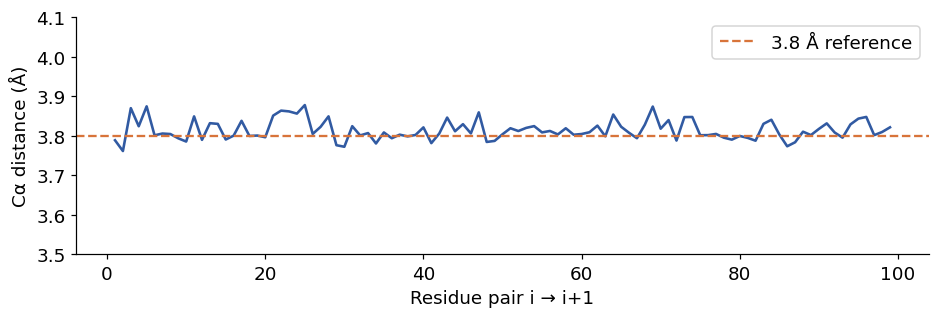

Final backbone figure: final_ca_trace.png | live run from this notebook


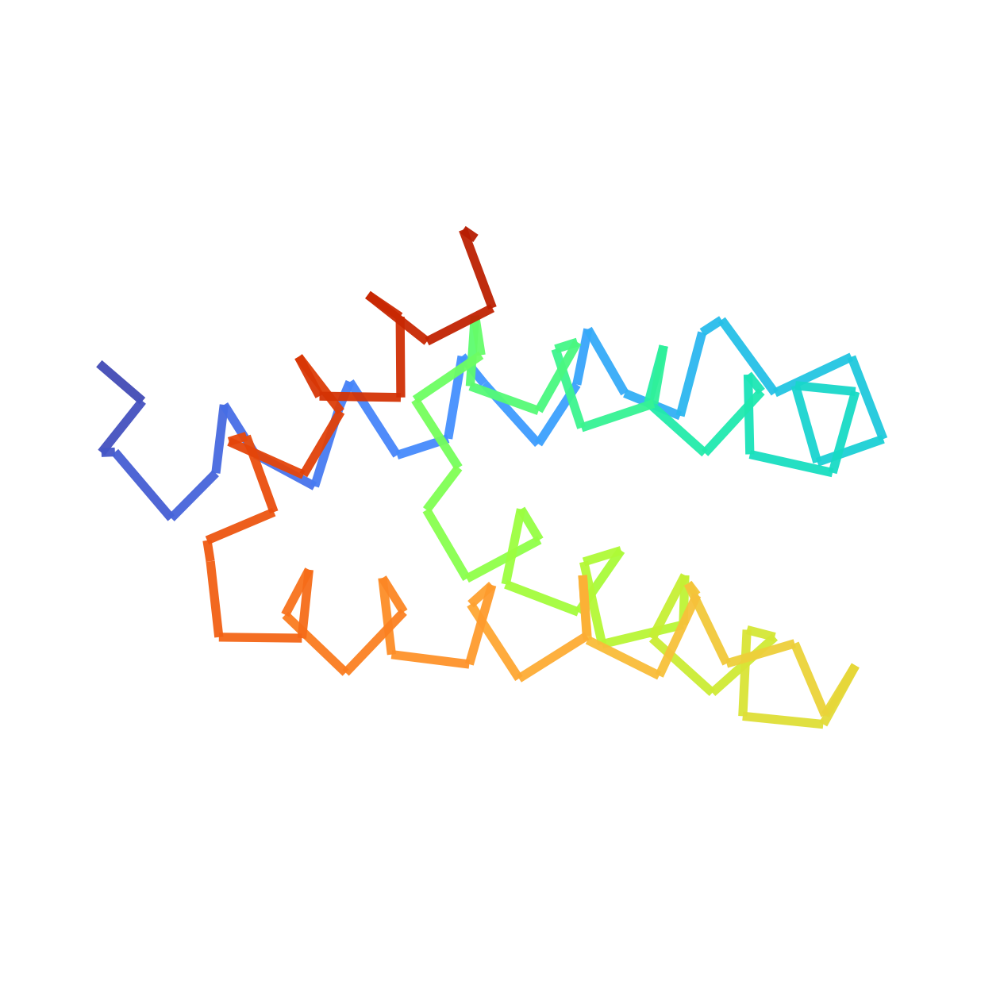

In [26]:
final_ca=ca[-1]
neighbor_distances=np.linalg.norm(np.diff(final_ca,axis=0),axis=1)
rg=np.sqrt(np.mean(np.sum((final_ca-final_ca.mean(axis=0))**2,axis=1)))
assert np.isfinite(ca).all()
assert np.isclose(neighbor_distances.mean(),protein_meta['ca_neighbor_distance_mean_A'],atol=1e-5)
print(f'Adjacent C-alpha distance: mean {neighbor_distances.mean():.3f} Å; range {neighbor_distances.min():.3f}–{neighbor_distances.max():.3f} Å')
print(f'Radius of gyration: {rg:.3f} Å')
fig,ax=plt.subplots(figsize=(10,2.8))
ax.plot(np.arange(1,len(neighbor_distances)+1),neighbor_distances,color=BLUE,lw=1.7)
ax.axhline(3.8,color=ORANGE,ls='--',label='3.8 Å reference')
ax.set(xlabel='Residue pair i → i+1',ylabel='Cα distance (Å)',ylim=(3.5,4.1))
ax.legend();plt.show()
# Recorded run: 3Dmol.js cartoon of the output PDB. Live run: matplotlib C-alpha trace of the same final coordinates.
final_figure = PROTEIN_DIR/'final_structure.png' if (PROTEIN_DIR/'final_structure.png').is_file() else PROTEIN_DIR/'final_ca_trace.png'
print('Final backbone figure:', final_figure.name, '|', run_source(PROTEIN_DIR, 'protein'))
display(Image(filename=str(final_figure),width=630))

## 17. Shared framework, different evidence requirements

| | Image generation | Protein design |
|:--|:--|:--|
| State | Pixel or learned latent tensor | Residue frames / atomic geometry |
| Example model | Stable Diffusion v1.5 | FrameFlow |
| Conditioning in this run | Text prompt + negative prompt | Length only; unconditional structure |
| Useful checks | Visual quality, prompt alignment, diversity | Geometry, sequence compatibility, refolding, experiments |
| Main limitation here | Prompt is only partially satisfied | A backbone is not a validated functional protein |

The recorded runtimes use different measurement scopes: image timing includes frame decoding and
saving, while protein timing covers model sampling. **They are not a cross-model speed benchmark.**

### Three takeaways

1. Diffusion learns how to denoise along a noise-corrupted probability path.
2. Flow matching learns a velocity compatible with a chosen probability path.
3. A shared generative framework supports different applications, but scientific claims require additional validation.

# Reproducibility and optional new inference

## 18. Files and environments on delta

Root: `/work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927`

| Purpose | Path relative to root |
|:--|:--|
| This notebook | `notebooks/Diffusion_Flow_Matching_Lecture_English.ipynb` |
| Recorded A100 results used by the CPU kernel | `notebooks/assets/` (links into the result directories below) |
| Live results written by the GPU kernel | `notebooks/live/image_generation/`, `notebooks/live/protein_design/` |
| GPU inference environment and kernel *Diffusion and Flow Lecture (GPU)* | `envs/lecture/` |
| CPU presentation environment and kernel *Diffusion and Flow Lecture (CPU)* | `envs/notebook/` |
| Shared inference and rendering code used by the notebook and by Slurm | `lecture_demos.py` |
| Command-line wrappers | `image_demo.py`, `protein_demo.py`, `render_image.py`, `render_protein.py` |
| Interactive A40 shell and JupyterLab launcher | `gpu_shell_a40.sh`, `launch_jupyter_gpu.sh` |
| Headless GPU execution of this notebook plus HTML export | `execute_notebook_gpu.sbatch` |
| Batch reruns of the canonical result directories | `run_demos_a40.sbatch` (A40), `run_demos.sbatch` (A100) |
| Stable Diffusion model and canonical results | `image_generation/model/`, `image_generation/results/` |
| FrameFlow code, weights and canonical results | `protein_design/FrameFlow/`, `protein_design/results/` |
| Dependency locks | `requirements.lock.txt` (GPU), `notebooks/requirements-notebook.lock.txt` (CPU) |

**Recorded inference jobs:** image `22456504`; protein `22456441`, both on an A100 40 GB.
The saved outputs in this notebook file come from a headless GPU execution with
`execute_notebook_gpu.sbatch`; the metadata printed in Sections 11 and 15 names the GPU and node.

**Provenance:** Stable Diffusion revision `451f4fe16113bff5a5d2269ed5ad43b0592e9a14`;
FrameFlow commit `f50d8dbbdae827be291e9f73d732b61b195f8816`.

In [14]:
# Display the exact commands. This cell does not submit a job or load a GPU model.
print(f'''# Live lecture on one A40 (interactive partition, 1 hour limit)
ssh delta
cd {DELTA_ROOT}
bash gpu_shell_a40.sh          # srun --account=bcrc-delta-gpu --partition=gpuA40x4-interactive --gpus-per-node=1 ... --pty bash
bash launch_jupyter_gpu.sh     # JupyterLab on the compute node; choose kernel "Diffusion and Flow Lecture (GPU)"

# Headless: re-execute this notebook on a GPU and refresh the HTML companion
sbatch execute_notebook_gpu.sbatch                        # partition gpuA40x4
sbatch -p gpuA40x4-interactive execute_notebook_gpu.sbatch

# Batch reruns that overwrite the canonical result directories
sbatch run_demos_a40.sbatch    # A40
sbatch run_demos.sbatch        # A100

# Inside any GPU allocation, the same code as the notebook cells:
source envs/lecture/bin/activate
python image_demo.py --seed 2026 --steps 50 --out notebooks/live/image_generation
python protein_demo.py --length 100 --steps 100 --seed 2026 --out notebooks/live/protein_design
python render_protein.py --out notebooks/live/protein_design
''')

# Live lecture on one A40 (interactive partition, 1 hour limit)
ssh delta
cd /work/nvme/bcrc/dzhang5/diffusion_flow_lecture_20260927
bash gpu_shell_a40.sh          # srun --account=bcrc-delta-gpu --partition=gpuA40x4-interactive --gpus-per-node=1 ... --pty bash
bash launch_jupyter_gpu.sh     # JupyterLab on the compute node; choose kernel "Diffusion and Flow Lecture (GPU)"

# Headless: re-execute this notebook on a GPU and refresh the HTML companion
sbatch execute_notebook_gpu.sbatch                        # partition gpuA40x4
sbatch -p gpuA40x4-interactive execute_notebook_gpu.sbatch

# Batch reruns that overwrite the canonical result directories
sbatch run_demos_a40.sbatch    # A40
sbatch run_demos.sbatch        # A100

# Inside any GPU allocation, the same code as the notebook cells:
source envs/lecture/bin/activate
python image_demo.py --seed 2026 --steps 50 --out notebooks/live/image_generation
python protein_demo.py --length 100 --steps 100 --seed 2026 --out notebooks/live/protei

All GPU scripts request account `bcrc-delta-gpu`, one GPU, eight CPUs and 48 GB of memory.
`gpu_shell_a40.sh` uses partition `gpuA40x4-interactive` (limit one hour, usually allocated within
minutes); the batch scripts use `gpuA40x4` or `gpuA100x4`. Run model inference on an allocated compute
node only; the login nodes have no GPU and the notebook then falls back to the recorded run.

The notebook writes live results to `notebooks/live/` and never touches `notebooks/assets/` or the
canonical result directories. Only `run_demos.sbatch` and `run_demos_a40.sbatch` overwrite the canonical
directories; copy them first if you want to keep the original trajectories.

`launch_jupyter_gpu.sh` starts JupyterLab bound to loopback on the compute node and prints the matching
SSH port-forward command for the laptop. Both kernels are visible in that server; the GPU kernel runs
`envs/lecture/bin/python`, which has PyTorch 2.5.1 with CUDA 12.4, Diffusers, FrameFlow's dependencies,
`ipykernel` and `ipywidgets`. A persistent Jupyter server is not started by executing this notebook.

## 19. Primary references

1. Sohl-Dickstein et al. **Deep Unsupervised Learning using Nonequilibrium Thermodynamics.** ICML 2015. [Paper](https://arxiv.org/abs/1503.03585)
2. Ho, Jain & Abbeel. **Denoising Diffusion Probabilistic Models.** NeurIPS 2020. [Paper](https://arxiv.org/abs/2006.11239)
3. Song, Meng & Ermon. **Denoising Diffusion Implicit Models.** ICLR 2021. [Paper](https://arxiv.org/abs/2010.02502)
4. Song et al. **Score-Based Generative Modeling through Stochastic Differential Equations.** ICLR 2021. [Paper](https://arxiv.org/abs/2011.13456)
5. Lipman et al. **Flow Matching for Generative Modeling.** ICLR 2023. [Paper](https://arxiv.org/abs/2210.02747)
6. Rombach et al. **High-Resolution Image Synthesis with Latent Diffusion Models.** CVPR 2022. [Paper](https://arxiv.org/abs/2112.10752)
7. Ho & Salimans. **Classifier-Free Diffusion Guidance.** 2022. [Paper](https://arxiv.org/abs/2207.12598)
8. Watson et al. **De novo design of protein structure and function with RFdiffusion.** Nature 2023. [Paper](https://doi.org/10.1038/s41586-023-06415-8)
9. Ingraham et al. **Illuminating protein space with a programmable generative model.** Nature 2023. [Paper](https://doi.org/10.1038/s41586-023-06728-8)
10. Yim et al. **Fast protein backbone generation with SE(3) flow matching.** 2023. [Paper](https://arxiv.org/abs/2310.05297)
11. Yim et al. **Improved motif-scaffolding with SE(3) flow matching.** TMLR 2024. [Paper](https://arxiv.org/abs/2401.04082) · [Official code](https://github.com/microsoft/protein-frame-flow)

### Discussion prompts

- Why can a deterministic denoising sampler generate diverse images across seeds?
- Why can the marginal flow be curved when its conditional training paths are straight?
- Which additional evidence would be needed to claim that a generated backbone is a functional protein?